In [ ]:
#Import Python Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.formula.api import logit
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

In [ ]:
#Read in the dataset
census_data = pd.read_csv('census-adult data.csv')

In [ ]:
#Print the first 5 rows of the dataset
census_data.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income_class
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


In [ ]:
#Calculate summary statistics
census_data.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32560.000000,3.256000e+04,32560.000000,32560.000000,32560.000000,32560.000000
mean,38.581634,1.897818e+05,10.080590,1077.615172,87.306511,40.437469
std,13.640642,1.055498e+05,2.572709,7385.402999,402.966116,12.347618
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178315e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783630e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370545e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
#Convert '>50K' to 1 and '<=50K' to 0 in income_class
#Had to strip the data first in order to make this work -- extra spaces somewhere in the column
census_data['income_class'] = census_data['income_class'].str.strip()
census_data['income_class_num'] = census_data['income_class'].replace({'<=50K': 0, '>50K': 1})

<ipython-input-44-c7b5f22f5004>:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  census_data['income_class_num'] = census_data['income_class'].replace({'<=50K': 0, '>50K': 1})


In [ ]:
#Check to make sure this worked
census_data['income_class_num'].value_counts()

,count
income_class_num,
0,24719
1,7841


In the sample, 24,719 people had incomes less than or equal to 50K, and 7,841 people had incomes greater than 50K.

In [ ]:
#Double check that income_class_num is in the dataframe
census_data.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income_class,income_class_num
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K,0


In [ ]:
#Strip the whitespace and make everything lowercase for more consistent formatting to being transforming all to numerical
census_data['workclass'] = census_data['workclass'].str.strip().str.lower()
census_data['education'] = census_data['education'].str.strip().str.lower()
census_data['marital_status'] = census_data['marital_status'].str.strip().str.lower()
census_data['occupation'] = census_data['occupation'].str.strip().str.lower()
census_data['relationship'] = census_data['relationship'].str.strip().str.lower()
census_data['race'] = census_data['race'].str.strip().str.lower()
census_data['sex'] = census_data['sex'].str.strip().str.lower()
census_data['native_country'] = census_data['native_country'].str.strip().str.lower()

In [ ]:
#Use mapping to create numerical dictionaries for each categorical variable
workclass_mapping = {
    'private': 0,
    'self-emp-not-inc': 1,
    'self-emp-inc': 2,
    'federal-gov': 3,
    'local-gov': 4,
    'state-gov': 5,
    'without-pay': 6,
    'never-worked': 7
}

education_mapping = {
    'bachelors': 0,
    'some-college': 1,
    '11th': 2,
    'hs-grad': 3,
    'prof-school': 4,
    'assoc-acdm': 5,
    'assoc-voc': 6,
    '9th': 7,
    '7th-8th': 8,
    '12th': 9,
    'masters': 10,
    '1st-4th': 11,
    '10th': 12,
    'doctorate': 13,
    '5th-6th': 14,
    'preschool': 15
}

marital_status_mapping = {
    'married-civ-spouse': 0,
    'divorced': 1,
    'never-married': 2,
    'separated': 3,
    'widowed': 4,
    'married-spouse-absent': 5,
    'married-af-spouse': 6
}

occupation_mapping = {
    'tech-support': 0,
    'craft-repair': 1,
    'other-service': 2,
    'sales': 3,
    'exec-managerial': 4,
    'prof-specialty': 5,
    'handlers-cleaners': 6,
    'machine-op-inspct': 7,
    'adm-clerical': 8,
    'farming-fishing': 9,
    'transport-moving': 10,
    'priv-house-serv': 11,
    'protective-serv': 12,
    'armed-forces': 13
}

relationship_mapping = {
    'wife': 0,
    'own-child': 1,
    'husband': 2,
    'not-in-family': 3,
    'other-relative': 4,
    'unmarried': 5
}

race_mapping = {
    'white': 0,
    'asian-pac-islander': 1,
    'amer-indian-eskimo': 2,
    'other': 3,
    'black': 4
}

sex_mapping = {
    'female': 0,
    'male': 1
}

native_country_mapping = {
    'united-states': 0,
    'cambodia': 1,
    'england': 2,
    'puerto-rico': 3,
    'canada': 4,
    'germany': 5,
    'outlying-us(guam-usvi-etc)': 6,
    'india': 7,
    'japan': 8,
    'greece': 9,
    'south': 10,
    'china': 11,
    'cuba': 12,
    'iran': 13,
    'honduras': 14,
    'philippines': 15,
    'italy': 16,
    'poland': 17,
    'jamaica': 18,
    'vietnam': 19,
    'mexico': 20,
    'portugal': 21,
    'ireland': 22,
    'france': 23,
    'dominican-republic': 24,
    'laos': 25,
    'ecuador': 26,
    'taiwan': 27,
    'haiti': 28,
    'columbia': 29,
    'hungary': 30,
    'guatemala': 31,
    'nicaragua': 32,
    'scotland': 33,
    'thailand': 34,
    'yugoslavia': 35,
    'el-salvador': 36,
    'trinidad&tobago': 37,
    'peru': 38,
    'hong': 39,
    'holand-netherlands': 40
}


In [ ]:
#Apply the mapping to each categorical column
census_data['workclass_num'] = census_data['workclass'].map(workclass_mapping).fillna(-1).astype(int)
census_data['education_num'] = census_data['education'].map(education_mapping).fillna(-1).astype(int)
census_data['marital_status_num'] = census_data['marital_status'].map(marital_status_mapping).fillna(-1).astype(int)
census_data['occupation_num'] = census_data['occupation'].map(occupation_mapping).fillna(-1).astype(int)
census_data['relationship_num'] = census_data['relationship'].map(relationship_mapping).fillna(-1).astype(int)
census_data['race_num'] = census_data['race'].map(race_mapping).fillna(-1).astype(int)
census_data['sex_num'] = census_data['sex'].map(sex_mapping).fillna(-1).astype(int)
census_data['native_country_num'] = census_data['native_country'].map(native_country_mapping).fillna(-1).astype(int)

#Now, all categorical variables should be transformed to numerical format
census_data.head()


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,...,native_country,income_class,income_class_num,workclass_num,marital_status_num,occupation_num,relationship_num,race_num,sex_num,native_country_num
0,50,self-emp-not-inc,83311,bachelors,0,married-civ-spouse,exec-managerial,husband,white,male,...,united-states,<=50K,0,1,0,4,2,0,1,0
1,38,private,215646,hs-grad,3,divorced,handlers-cleaners,not-in-family,white,male,...,united-states,<=50K,0,0,1,6,3,0,1,0
2,53,private,234721,11th,2,married-civ-spouse,handlers-cleaners,husband,black,male,...,united-states,<=50K,0,0,0,6,2,4,1,0
3,28,private,338409,bachelors,0,married-civ-spouse,prof-specialty,wife,black,female,...,cuba,<=50K,0,0,0,5,0,4,0,12
4,37,private,284582,masters,10,married-civ-spouse,exec-managerial,wife,white,female,...,united-states,<=50K,0,0,0,4,0,0,0,0


In [ ]:
#Create census_data_num that has dropped all of the non numerical columns
census_data_num = census_data.drop(columns=['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'income_class'])

In [ ]:
#Create a correlation matrix
correlation_matrix = census_data_num.corr()
correlation_matrix

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,income_class_num,workclass_num,marital_status_num,occupation_num,relationship_num,race_num,sex_num,native_country_num
age,1.000000,-0.076646,0.121301,0.077674,0.057775,0.068756,0.234039,0.109787,-0.220941,0.000991,0.128919,-0.029869,0.088832,-0.038635
fnlwgt,-0.076646,1.000000,0.019498,0.000437,-0.010259,-0.018770,-0.009481,-0.024206,0.024105,0.004569,0.014790,0.098396,0.026882,0.098582
education_num,0.121301,0.019498,1.000000,0.019889,0.016917,0.009360,0.009100,0.026920,-0.013245,0.000460,0.031105,0.009108,0.034297,0.152830
capital_gain,0.077674,0.000437,0.019889,1.000000,-0.031614,0.078409,0.223333,0.018290,-0.074313,-0.004583,-0.026658,-0.019989,0.048477,-0.016252
capital_loss,0.057775,-0.010259,0.016917,-0.031614,1.000000,0.054256,0.150523,0.025706,-0.066962,-0.006554,-0.030637,-0.023928,0.045572,-0.021673
hours_per_week,0.068756,-0.018770,0.009360,0.078409,0.054256,1.000000,0.229690,0.069742,-0.221883,0.104420,0.056941,-0.054444,0.229312,-0.014709
income_class_num,0.234039,-0.009481,0.009100,0.223333,0.150523,0.229690,1.000000,0.102788,-0.377786,-0.007723,-0.171763,-0.096846,0.215995,-0.056802
workclass_num,0.109787,-0.024206,0.026920,0.018290,0.025706,0.069742,0.102788,1.000000,-0.072863,0.221966,0.022597,0.025866,0.012340,-0.050583
marital_status_num,-0.220941,0.024105,-0.013245,-0.074313,-0.066962,-0.221883,-0.377786,-0.072863,1.000000,-0.018331,0.362812,0.131793,-0.380067,0.048410
occupation_num,0.000991,0.004569,0.000460,-0.004583,-0.006554,0.104420,-0.007723,0.221966,-0.018331,1.000000,0.028348,0.027646,-0.011365,0.004137


<Figure size 1400x1000 with 0 Axes>

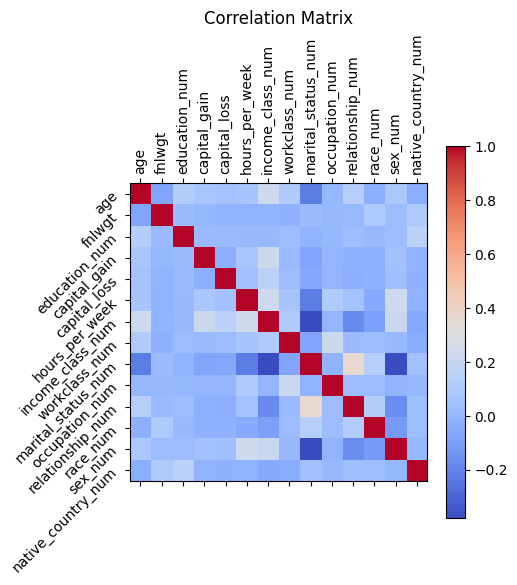

In [ ]:
#Create a visual Correlation Matrix using matplotlib
plt.figure(figsize=(14, 10))
plt.matshow(correlation_matrix, cmap='coolwarm') ## Actual correlation plot
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.colorbar() ## For the bar representing scale on the right
plt.title('Correlation Matrix')
plt.show()

In [ ]:
#Select three features to use as predictor variables and the target varibale
X = census_data[['age', 'hours_per_week', 'education_num']]
y = census_data['income_class_num']

I selected the three variables "age", "hours_per_week", and "education_num" because I feel like they demonstrate the required information used to predict someone's income. First, I selected age because I feel that someone's income is largely dependent on their age. For example, many younger individuals, such as teenagers, are not usually seen as having a high income. Next, I selected the variable "hours_per_week" which demonstrates the numeric amount of hours someone works a week. I picked this feature because hours worked is likely to impact income, especially for people paid hourly. Finally, I picked "education_num" because someone's level of education typically influences which type of job they are able to get, which ultimately should impact their income. More educated people have access to more complex jobs, that are typically higher paying. I feel that all three of these variables combined should accurately predict a person's income class as they cover a wide range of factors that could influence income class.

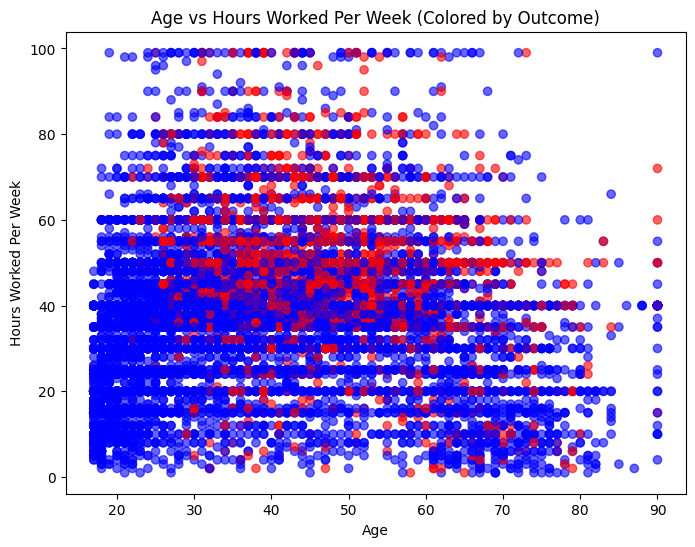

In [ ]:
# Scatterplot of selected features (Age vs Hours Worked Per Week)
plt.figure(figsize=(8, 6))
colors = ['red' if label == 1 else 'blue' for label in census_data['income_class_num']]
plt.scatter(census_data['age'], census_data['hours_per_week'], c=colors, alpha=0.6)
plt.title('Age vs Hours Worked Per Week (Colored by Outcome)')
plt.xlabel('Age')
plt.ylabel('Hours Worked Per Week')
plt.show()

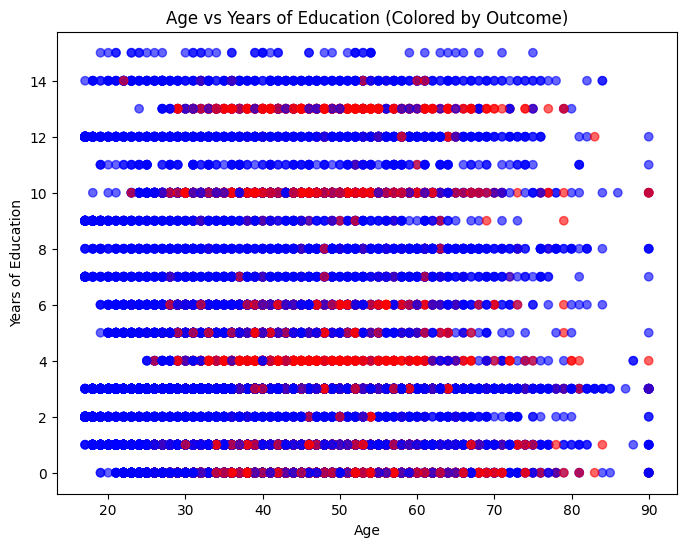

In [ ]:
# Scatterplot of selected features (Age vs Years of Education)
plt.figure(figsize=(8, 6))
colors = ['red' if label == 1 else 'blue' for label in census_data['income_class_num']]
plt.scatter(census_data['age'], census_data['education_num'], c=colors, alpha=0.6)
plt.title('Age vs Years of Education (Colored by Outcome)')
plt.xlabel('Age')
plt.ylabel('Years of Education')
plt.show()

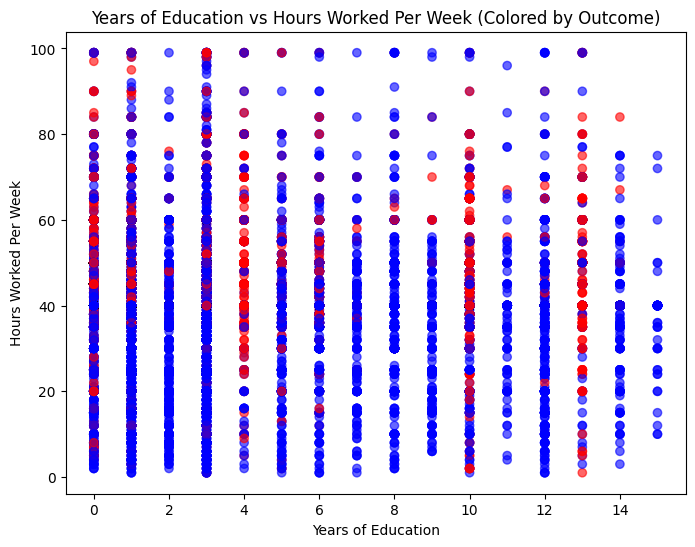

In [ ]:
# Scatterplot of selected features (Years of Education vs Hours Worked Per Week)
plt.figure(figsize=(8, 6))
colors = ['red' if label == 1 else 'blue' for label in census_data['income_class_num']]
plt.scatter(census_data['education_num'], census_data['hours_per_week'], c=colors, alpha=0.6)
plt.title('Years of Education vs Hours Worked Per Week (Colored by Outcome)')
plt.xlabel('Years of Education')
plt.ylabel('Hours Worked Per Week')
plt.show()

In [ ]:
#Run the regression
var_struct = "income_class_num ~ age + hours_per_week + education_num"

model =logit(var_struct, data = census_data).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.497573
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:       income_class_num   No. Observations:                32560
Model:                          Logit   Df Residuals:                    32556
Method:                           MLE   Df Model:                            3
Date:                Fri, 01 Nov 2024   Pseudo R-squ.:                 0.09863
Time:                        17:33:31   Log-Likelihood:                -16201.
converged:                       True   LL-Null:                       -17974.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -4.8834      0.075    -65.352      0.000      -5.030      -4.737
age              

Now we need to convert the output to an odds ratio to be able to interpret it.


In [ ]:
np.exp(model.params)

,0
Intercept,0.007571
age,1.044724
hours_per_week,1.049087
education_num,0.983066


When age increases by 1 year, the odds that the person will have an income greater than 50K dollars is 1.048 times as large as the odds that the person will have an income equal to or below 50K dollars, given that hours worked per week and education are held constant. When hours worked per week is increased by 1 hour, the odds that the person will have an income greater than 50K dollars is 1.044 times as large as the odds that the person will have an income equal to or below 50K dollars, given that age and education are held constant. Finally, when years of education is increased by 1 year, the odds that the person will have an income greater than 50K dollars is 1.413 times as large as the odds that the person will have an income equal to or below 50K dollars, given that age and hours worked per week are held constant.

In [ ]:
from sklearn.model_selection import train_test_split

#Split the data into training data and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [ ]:
y_test

,income_class_num
14160,0
27047,0
28867,1
5667,1
7827,0
...,...
27166,0
32475,0
21100,0
27130,0


In [ ]:
#Check the sizes of the training and testing data samples
print("Size of Training Samples: ", len(y_train))
print("Size of Testing Samples: ", len(y_test))

Size of Training Samples:  22792
Size of Testing Samples:  9768


In [ ]:
#Start to build the logistic regression model for scikit-learn
model2 = LogisticRegression(random_state=42)
model2.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [ ]:
#Make predictions using the test set
y_pred = model2.predict(X_test)

In [ ]:
#Find the accuracy score of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(f"Accuracy Rounded: {accuracy:.2f}")
print(f"Accuracy (%): {accuracy*100:.2f}%")

Accuracy: 0.7514332514332515
Accuracy Rounded: 0.75
Accuracy (%): 75.14%


In [ ]:
# Create a confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[7119,  276],
       [2152,  221]])

From the confusion matrix, I found that there were 221 true positives, 2152 false negatives, 276 false positives, and 7119 true negatives. The model correctly predicted that an individual earned more than 50K dollars for 221 cases, and it correctly predicted that an individual earned less than or equal to 50,000 dollars in 7119 cases. The model incorrectly predicted that an individual does not earn more than $50,000 when they actually do in 2152 cases, and it incorrectly predicted that an individual earns more than 50,000 dollars a year when they actually do not in 276 cases.



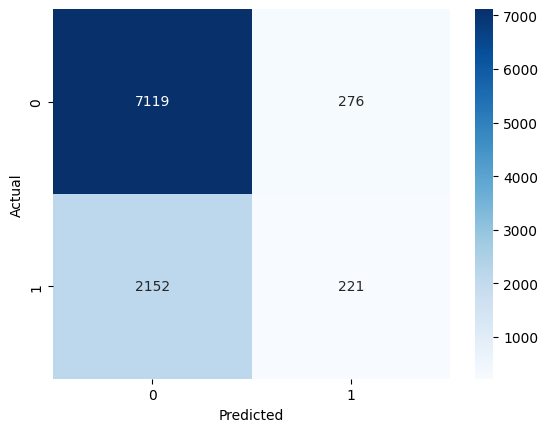

In [ ]:
#Create a heatmap using seaborn and matplotlib libraries
sns.heatmap(cm, annot=True, cmap='Blues', cbar=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

The model correctly predicted that an individual earned more than 50K dollars for 221 cases, and it correctly predicted that an individual earned less than or equal to 50,000 dollars in 7119 cases. The model incorrectly predicted that an individual does not earn more than $50,000 when they actually do in 2152 cases, and it incorrectly predicted that an individual earns more than 50,000 dollars a year when they actually do not in 276 cases.

In [ ]:
#Calculate precision
precision = precision_score(y_test, y_pred, average = None)
print("Precision:", precision)

Precision: [0.76787833 0.44466801]


76.79% of the instances predicted as having an income equal to or below 50,000 dollars are correct. 44.47% of the instances predicted as having an income above 50,000 dolalrs are correct.

In [ ]:
#Calculate recall
recall = recall_score(y_test, y_pred, average=None)
print("Recall:", recall)

Recall: [0.96267748 0.09313106]


Of all the actual instances with an income below 50,000 dollars, the model correctly identified about 96.27%, so it was able to effectively capture most of the individuals whose income is below 50,000 dollars. On the other hand, from all of the actual instances with an income above 50,000 dollars, the model only correctly identified about 9.31%.

In [ ]:
#Calculate F1-score
f1 = f1_score(y_test, y_pred, average=None)
print("F1-Score:", f1)

F1-Score: [0.85431417 0.15400697]


The F1 score indicates the balance between precision and recall for the predictions. For identifying people who make less than or equal to 50,000 dollars, the F1 score was 85.43%. This means that the model is performing well and is balancing the correct predictions against the errors.

When identiying people who have an income above 50,000 dollars, the model preformed poorly. This has a F1 score of 15.4%, which shows that it is not being persice and is missing a lot of true positives in this case.

In [ ]:
#Print an overall classification report
report = classification_report(y_test, y_pred)
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.96      0.85      7395
           1       0.44      0.09      0.15      2373

    accuracy                           0.75      9768
   macro avg       0.61      0.53      0.50      9768
weighted avg       0.69      0.75      0.68      9768

